# NODE / UDE - Remaining Useful Life (NASA C-MAPSS)

Este notebook implementa:

- Preprocesamiento de datos
- Construcción y desarrollo de modelo de probabilidad
- NODE (Neural ODE)
- UDE (Universal Differential Equation)

In [1]:
using Pkg
Pkg.activate(".")



#solo la primera vez:
#Pkg.instantiate()

  Activating project at `c:\Users\Sebastian\Desktop\TP-DegradacionDeMotores\mi_entorno`


## Todas los paquetes que utilizaremos.

In [2]:
ENV["GKSwstype"] = "100"

using CSV
using DataFrames
using Statistics
using Plots

using Lux
using ComponentArrays
using Random
Random.seed!(42)

using OrdinaryDiffEq
using SciMLSensitivity

using Optimization
using OptimizationOptimisers
using Zygote
using DataInterpolations

## Carga de datos

In [3]:
dataset_path = joinpath(pwd(), "..", "CMaps", "train_FD001.txt")

train_df = CSV.read(
    dataset_path,
    DataFrame;
    delim=' ',
    ignorerepeated=true,
    header=false
)


#agregamos los nombres de la columnas ya que el dataset original venian sin ellos
rename!(
    train_df,
    vcat(
        ["unit", "cycle", "setting1", "setting2", "setting3"],
        ["s$i" for i in 1:21]
    )
)

first(train_df, 5)

Row,unit,cycle,setting1,setting2,setting3,s1,s2,s3,s4,s5,s6,s7,s8,s9,s10,s11,s12,s13,s14,s15,s16,s17,s18,s19,s20,s21
,Int64,Int64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Int64,Int64,Float64,Float64,Float64
1,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.7,1400.6,14.62,21.61,554.36,2388.06,9046.19,1.3,47.47,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.419
2,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,21.61,553.75,2388.04,9044.07,1.3,47.49,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.0,23.4236
3,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.2,14.62,21.61,554.26,2388.08,9052.94,1.3,47.27,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
4,1,4,0.0007,0.0,100.0,518.67,642.35,1582.79,1401.87,14.62,21.61,554.45,2388.11,9049.48,1.3,47.13,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
5,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,21.61,554.0,2388.06,9055.15,1.3,47.28,522.19,2388.04,8133.8,8.4294,0.03,393,2388,100.0,38.9,23.4044


## Normalización de sensores y settings

In [4]:
#Normalizamos los datos de los sensores y settings para mejorar entrenamiento de redes neuronales.


sensor_cols = ["s$i" for i in 1:21]
setting_cols = ["setting1", "setting2", "setting3"]
    
for col in sensor_cols
    μ = mean(train_df[!, col])
    σ_col = std(train_df[!, col])
    train_df[!, col] = (train_df[!, col] .- μ) ./ σ_col
end
    
for col in setting_cols
    μ = mean(train_df[!, col])
    σ_col = std(train_df[!, col])
    train_df[!, col] = (train_df[!, col] .- μ) ./ σ_col
end

## Modelado de la falla mediante análisis de supervivencia

Inicialmente, la probabilidad de falla se construía a partir del RUL (Remaining Useful Life) utilizando una transformación sigmoidal:

$$
p_{\text{fail}} = \sigma(k(\text{threshold} - RUL))
$$

Sin embargo, esta construcción introduce supuestos arbitrarios, ya que tanto la forma funcional como los parámetros utilizados no provienen directamente de los datos observados.

Para evitar este problema, reformulamos el problema como uno de **supervivencia discreta**.

### Variable objetivo

Para cada instante temporal \(t\) de una trayectoria, definimos la variable objetivo:

$$
y_t =
\begin{cases}
1 & \text{si el motor falla en el ciclo t}\\
0 & \text{si el motor continúa funcionando}
\end{cases}
$$

Dado que en el dataset de entrenamiento cada trayectoria finaliza en la falla, la última observación de cada motor recibe la etiqueta 1 y todas las observaciones anteriores reciben la etiqueta 0.

### Modelo

Se mantiene la estructura dinámica basada en Neural Ordinary Differential Equations (NODEs). El estado latente \(z(t)\) evoluciona según

$$
\frac{dz}{dt}=f_\theta(z(t),x(t)),
$$

donde \(x(t)\) representa las mediciones de sensores y condiciones operativas.

A partir del estado latente se obtiene una probabilidad mediante una capa de salida sigmoidal:

$$
h_t = \sigma(g_\theta(z_t)).
$$

Esta cantidad se interpreta como la probabilidad de que el motor falle en el próximo ciclo, condicionada a haber sobrevivido hasta el instante actual.

### Entrenamiento

El entrenamiento se realiza mediante máxima verosimilitud para supervivencia discreta. Para una trayectoria que falla en el ciclo \(T\), la probabilidad observada es

$$
P(T)=\left(\prod_{t=1}^{T-1}(1-h_t)\right)h_T.
$$

Equivalentemente, se minimiza la log-verosimilitud negativa:

$$
\mathcal{L}
=
-\sum_{t=1}^{T-1}\log(1-h_t)
-\log(h_T).
$$

Esta formulación permite obtener probabilidades de falla directamente a partir de los datos observados, sin necesidad de construir etiquetas probabilísticas artificiales a partir del RUL.

In [5]:
train_df.event = zeros(Int, nrow(train_df))

for g in groupby(train_df, :unit)
    idx = parentindices(g)[1][end]
    train_df.event[idx] = 1
end



Verificamos:

In [6]:
combine(groupby(train_df, :unit), :event => sum) 
#deberia dar 1 por cada motor

Row,unit,event_sum
,Int64,Int64
1,1,1
2,2,1
3,3,1
4,4,1
5,5,1
6,6,1
7,7,1
8,8,1
9,9,1


## Ejemplo de la nueva columna

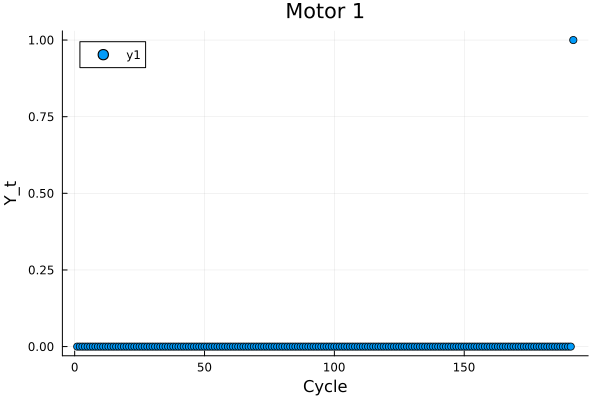

In [7]:
motor1 = filter(row -> row.unit == 1, train_df)
    
plt = scatter(
    motor1.cycle,
    motor1.event,
    xlabel="Cycle",
    ylabel="Y_t",
    title="Motor 1"
)
    
plt

## Trayectorias por motor

In [8]:
#agrupamos por unidad
grouped = groupby(train_df, :unit)
    
trajectories = []
    
for g in grouped
    X = Matrix(g[:, vcat(setting_cols, sensor_cols)])
    y = g.event
    t = g.cycle
    
    push!(trajectories, (X=X, y=y, t=t))
end

## NODE

$$
\frac{dz}{dt} =  NN(z,t)
$$

El primer modelo que vamos a probar es una NODE sin utilizar información de los sensores. Luego aplicamos sigmoide como habíamos comentado antes

In [9]:
#elegimos una trayectoria
traj = trajectories[1]

print(trajectories)

t = Float64.(traj.t)
y = Float64.(traj.y)
    
u0 = [-10.0] #Para el baseline ponemos cond inicial que haga dar una proba chica. Despues lo podemos ir cambiando
    
#generador de numeros aleatorios, sirve para inicializar los pesos de la red
rng = Random.default_rng()

#estructura de la red
nn = Lux.Chain(
    Lux.Dense(2, 16, tanh),
    Lux.Dense(16, 1)
)

#p: parametros entrenables de la red, st: estados internos
p_node, st_node = Lux.setup(rng, nn)
#esto es para que funcione bien la optimizacion
p_node = ComponentArray(p_node)

Any[(X = [-0.31597202195452145 -1.3729199290729734 NaN 0.9999757643323645 -1.7216836648226865 -0.13425192213570927 -0.925913523696359 -0.9999757643323643 0.14167989491882235 1.1211133982073023 -0.516325892386186 -0.8627924043441415 0.9999757643323643 -0.2664601377187745 0.33425373913469153 -1.0588645739680291 -0.26906451920303553 -0.603801065881639 -0.9999757643323645 -0.7816908404632746 NaN NaN 1.3484600620382499 1.1943981001535333; 0.8727007771683792 -1.0316953503320596 NaN 0.9999757643323645 -1.0617539738121262 0.2115233673416215 -0.6437102649230355 -0.9999757643323643 0.14167989491882235 0.4319197071333588 -0.7980736570341316 -0.9587943771663178 0.9999757643323643 -0.1915782821843463 1.174870847738156 -0.3636371846989997 -0.6428291567796645 -0.27584512524895916 -0.9999757643323645 -0.7816908404632746 NaN NaN 1.0165032941737064 1.2368919830975704; -1.9618266668939224 1.015652122113423 NaN 0.9999757643323645 -0.6617965853206986 -0.4131555754405577 -0.5259404010255218 -0.9999757643323

Excessive output truncated after 524291 bytes.

-0.3150585244238024; 0.8727007771683792 -0.6904707715911458 NaN 0.9999757643323645 -0.40182428280133875 -0.3299737841040272 0.18178981881144884 -0.9999757643323643 0.14167989491882235 -0.5510286719392979 0.8924129308535417 -0.7971306776498028 0.9999757643323643 0.44491748985817403 -0.2080798793191217 1.3049085495390833 -1.2467237745752495 0.50271694519599 -0.9999757643323645 0.5096623027963773 NaN NaN -0.5879544171715211 -1.0328356341524414; 0.1412098238619788 -0.6904707715911458 NaN 0.9999757643323645 0.11812032223738084 0.40724522930993945 0.7239756073207978 -0.9999757643323643 0.14167989491882235 -0.6753095014772349 0.18804351923688095 -1.1630249891605973 0.9999757643323643 0.4823584176254015 -0.5063633694687729 -0.5026826625553349 -0.9867135919132489 0.6866922289655166 -0.9999757643323645 0.5096623027963773 NaN NaN -0.698606673126382 -1.29980807264868; -0.13309928362792137 0.6744275433725094 NaN 0.9999757643323645 0.9180350992200089 -0.948128664820602 0.07957446524003368 -0.9999757

ComponentVector{Float32}(layer_1 = (weight = Float32[-0.18582273 0.073365726; -1.3326262 1.9626849; … ; -1.2206342 0.22496898; 1.2360227 0.50070494], bias = Float32[0.45274794, -0.109943174, 0.2535509, 0.33633876, -0.58940434, -0.5645052, -0.6811371, -0.25305128, 0.11489113, 0.6639945, -0.4025346, -0.6888659, -0.4826754, 0.3613354, 0.48929778, -0.21674016]), layer_2 = (weight = Float32[0.3199716 0.046035804 … 0.03958083 -0.19888853], bias = Float32[-0.0893096]))

Definimos la NODE

In [10]:
function node!(du, u, p, t)
    input = [u[1], t]

    du .= nn(input, p, st_node)[1]
end

node! (generic function with 1 method)

In [11]:
#todo el intervalo de tiempo
tspan = (t[1], t[end])
	
#definimos el problema de ode
prob_node = ODEProblem(node!, u0, tspan, p_node)
	
#resolvemos con solver numerico
sol = solve(prob_node, Tsit5(), saveat=t)

#Al no haber entrenado el sistema, no se obtienen buenos resultados por ahora

┌ Warning: Mixed-Precision `matmul_cpu_fallback!` detected and Octavian.jl cannot be used for this set of inputs (C [Matrix{Float64}]: A [Base.ReshapedArray{Float32, 2, SubArray{Float32, 1, Vector{Float32}, Tuple{UnitRange{Int64}}, true}, Tuple{}}] x B [Matrix{Float64}]). Falling back to generic implementation. This may be slow.
└ @ LuxLib.Impl C:\Users\Sebastian\.julia\packages\LuxLib\zPBrt\src\impl\matmul.jl:194


retcode: Success
Interpolation: 1st order linear
t: 192-element Vector{Float64}:
   1.0
   2.0
   3.0
   4.0
   5.0
   6.0
   7.0
   8.0
   9.0
  10.0
  11.0
  12.0
  13.0
   ⋮
 181.0
 182.0
 183.0
 184.0
 185.0
 186.0
 187.0
 188.0
 189.0
 190.0
 191.0
 192.0
u: 192-element Vector{Vector{Float64}}:
 [-10.0]
 [-8.780622759474427]
 [-7.5805077916837496]
 [-6.720907178753919]
 [-6.174018158692469]
 [-5.783400814511278]
 [-5.452365599762099]
 [-5.192293643108463]
 [-5.19810144592661]
 [-5.43733644400067]
 [-5.753428302551949]
 [-6.080326618890222]
 [-6.392108509421911]
 ⋮
 [-72.39145382643432]
 [-72.79646555484896]
 [-73.2014860303423]
 [-73.60651456251976]
 [-74.01155045969172]
 [-74.41659302887358]
 [-74.82164157578565]
 [-75.22669540485325]
 [-75.6317538192067]
 [-76.03681612068124]
 [-76.44188160981709]
 [-76.84694958585948]

### Entrenamiento NODE

In [12]:
#definimos la funcion sigmoide:
σ(x) = 1 / (1 + exp(-x))


#funcion de prediccion
function predict(prob, p, t)

    _prob = remake(prob, p=p)

    sol = solve(
        _prob,
        Tsit5(),
        saveat=t
    )

    z_pred = Array(sol)[1, :]
    h_pred = σ.(z_pred)

    return h_pred
end

#funcion de perdida: verosimilitud de la trayectoria
function loss(prob, p, t, y)

    h = predict(prob, p, t)

    ϵ = 1f-7 #el epsilon es para no evaluar log(0)

    Tfail = findfirst(==(1), y)

    l = -sum(
        y .* log.(h .+ ϵ) .+
        (1 .- y) .* log.(1 .- h .+ ϵ)
    )

    return l
end

loss (generic function with 1 method)

In [13]:
#convertimos la funcion loss en algo digerible por el optimizador. Con AutoZygote() calculamos los gradientes.
optf_node = OptimizationFunction((x, _) -> loss(prob_node,x,t,y), AutoZygote())

#Define el problema de opt. Quiero minimizar optf empezando de parametros iniciales p.
optprob_node = OptimizationProblem(optf_node, p_node)

#Resulve el problema de opt. Con Adam version de descenso por el gradiente y 0.01 el learning rate.
result_node = Optimization.solve(optprob_node, Adam(0.01), maxiters=500)
	
p_trained_node = result_node.u

#prediccion final luego de entrenar:
pred_node = predict(prob_node, p_trained_node, t)

192-element Vector{Float64}:
 4.5397868702434395e-5
 1.572941636784752e-5
 5.322132732914268e-6
 1.5969751812734953e-6
 3.5474498425299597e-7
 6.50830421523749e-8
 1.1326647615183072e-8
 1.9388541165898763e-9
 3.2853603036558196e-10
 5.508299991519877e-11
 9.130852476363076e-12
 1.4963125420759114e-12
 2.4254522207159947e-13
 ⋮
 4.948538602757847e-149
 7.699982666077434e-150
 1.1981261098941375e-150
 1.8642979308672455e-151
 2.900868903816894e-152
 4.513785193770017e-153
 7.023501389088556e-154
 1.0928648494500086e-154
 1.7005102056682017e-155
 2.6460133300368993e-156
 4.1172270059957336e-157
 6.406452313162104e-158

Graficamos la sol obtenida

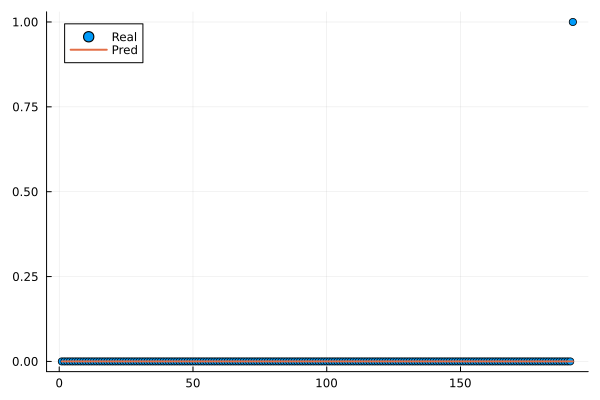

In [14]:
p1 = plot(
    t,
    y,
    seriestype = :scatter,
    label = "Real",
    markersize = 4
)

plot!(
    p1,
    t,
    pred_node,
    label = "Pred",
    linewidth = 2
)

p1

## UDE

Ahora además de tener un red neuronal en el sistema, agregamos un término físico a la ecuación diferencial.

$$
\frac{dz}{dt} = -\alpha z + NN(z, t)
$$

In [15]:
#Definimos la red
nn2 = Lux.Chain(
    Lux.Dense(2, 16, tanh),
    Lux.Dense(16, 1)
)

#parametros y estado interno
p_ude, st_ude = Lux.setup(rng, nn2)
p_ude = ComponentArray(p_ude)
    
α = 0.05

#definimos ude
function ude!(dz, z, p, t)

    input = [z[1], t]
    dz .= .-α .* z .+ nn2(input, p, st_ude)[1]

end

#definimos problema ode
prob_ude = ODEProblem(ude!, u0, tspan, p_ude)

#mismo proceso de antes
optf_ude = OptimizationFunction(
(x, _) -> loss(prob_ude,x,t,y),
AutoZygote()
)

optprob_ude = OptimizationProblem(optf_ude, p_ude)

result_ude = Optimization.solve(
    optprob_ude,
    Adam(0.01),
    maxiters=500
)

p_trained_ude = result_ude.u
pred_ude = predict(prob_ude, p_trained_ude, t)

192-element Vector{Float64}:
 4.5397868702434395e-5
 1.9857457265463165e-5
 1.0015235437388616e-5
 5.885035847926051e-6
 4.609551022899267e-6
 4.682053518466153e-6
 4.9441736964792406e-6
 5.2386940211093195e-6
 5.723246997615993e-6
 6.951122881420266e-6
 9.26245594621987e-6
 1.2637121303509673e-5
 1.692771115515821e-5
 ⋮
 0.003780358548998097
 0.0037806948749986393
 0.003781013212432617
 0.003781314753718315
 0.0037816006993591673
 0.0037818722578954037
 0.003782130645859085
 0.0037823770877325807
 0.003782612815910562
 0.0037828390706656496
 0.003783057100117729
 0.0037832681602071004

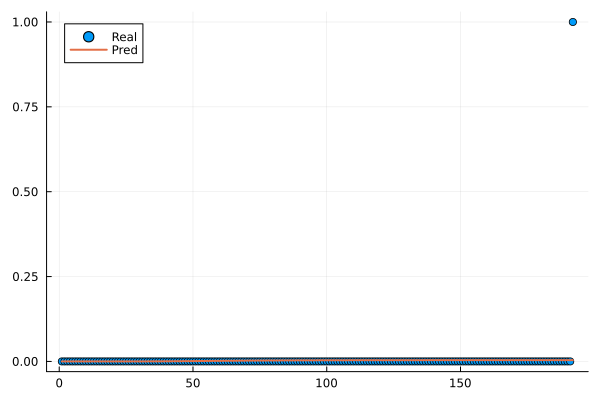

In [16]:
p1 = plot(
    t,
    y,
    seriestype = :scatter,
    label = "Real",
    markersize = 4
)

plot!(
    p1,
    t,
    pred_ude,
    label = "Pred",
    linewidth = 2
)

p1

Por ahora en los dos modelos que tenemos obtenemos un resultado constantemente 0. Veamos si al entrenar con más motores cambiamos esto

## Entrenamiento de UDE con más motores

Hasta ahora veníamos entrenando con una sola trayectoria y evavluando en la misma. Veamos que pasa si entrenamos con más de una trayectoria.

In [17]:
#Ahora tengamos en cuenta mas de una trayectoria de motor.

#hago una funcion para no practicar con todas las trajs a la ves, si no tarda demasiado

n_motors = length(trajectories)


function build_train_trajs(trajectories; n_motors=nothing, shuffle=false, seed=1234)

    total_motors = length(trajectories)

    if n_motors === nothing
        selected_ids = collect(1:total_motors)
    else
        n = min(n_motors, total_motors)
        println("usando $n de $total_motors motores")
        selected_ids = collect(1:n)
    end


    #esto recontraponele, capaz sirve capaz no, pero como el test te da cualquier motor esto lo hace mas random
    if shuffle
        rng = Random.default_rng()
        Random.seed!(rng, seed)
        selected_ids = selected_ids[randperm(rng, length(selected_ids))]
    end

    train_trajs = [
        (
            X = trajectories[i].X,
            t = Float64.(trajectories[i].t),
            y = Float64.(trajectories[i].y)
        )
        for i in selected_ids
    ]

    return train_trajs
end


function predict_traj(f!, p, traj)

    t = traj.t
    y = traj.y

    u0 = [-10.0] #seguimos con esta idea 
    tspan = (t[1], t[end])

    prob = ODEProblem(f!, u0, tspan, p)

    sol = solve(
        prob,
        Tsit5(),
        saveat=t,
        abstol=1e-6,
        reltol=1e-6
    )

    z_pred = Array(sol)[1, :]
    h_pred = σ.(z_pred)

    return h_pred
end


function loss_many(f!, p, trajs)

    total_loss = 0f0

    ϵ = 1f-7 #el epsilon es para no evaluar log(0)
    for traj in trajs
        h = predict_traj(f!, p, traj)
        y = traj.y

        total_loss += -sum(y .* log.(h .+ ϵ) .+ (1 .- y) .* log.(1 .- h .+ ϵ))
        
    end

    return total_loss / length(trajs) 
end

loss_many (generic function with 1 method)

In [18]:
# Definimos la red de la UDE
nn2 = Lux.Chain(
    Lux.Dense(2, 16, tanh),
    Lux.Dense(16, 1)
)

# Parámetros y estado interno
p_ude, st_ude = Lux.setup(rng, nn2)
p_ude = ComponentArray(p_ude)

# Parámetro fijo de la parte mecanística
α = 0.05

train_trajs = build_train_trajs(trajectories, n_motors=10)

#definimos un callback basico
callback = function (state, l)

    println("iter=$(state.iter), loss=$l")

    return false

end

optf_ude = OptimizationFunction(
    (x, _) -> loss_many(ude!, x, train_trajs),
    AutoZygote()
)

optprob_ude = OptimizationProblem(optf_ude, p_ude)

result_ude = Optimization.solve(
    optprob_ude,
    Adam(0.01),
    maxiters=500,
    callback = callback
)

p_trained_ude = result_ude.u

usando 10 de 100 motores
iter=1, loss=14.171933267404038
iter=2, loss=10.936950882242892
iter=3, loss=7.708757891849478
iter=4, loss=7.510526851251498
iter=5, loss=7.60989246112202
iter=6, loss=6.42714361053321
iter=7, loss=6.7364781044464905
iter=8, loss=7.1457520379419694
iter=9, loss=7.260978230617319
iter=10, loss=7.0672709621347565
iter=11, loss=6.666111420902449
iter=12, loss=6.277533978191035
iter=13, loss=6.283766329352138
iter=14, loss=6.671851892509707
iter=15, loss=6.448082013790104
iter=16, loss=6.102245768317548
iter=17, loss=6.13277081640115
iter=18, loss=6.284481347657764
iter=19, loss=6.34304316060902
iter=20, loss=6.259092465084004
iter=21, loss=6.093420027356251
iter=22, loss=5.987799642630975
iter=23, loss=6.065603670547534
iter=24, loss=6.165259901647025
iter=25, loss=6.0550805949818205
iter=26, loss=5.946010489053334
iter=27, loss=5.970522476405646
iter=28, loss=6.029982086992485
iter=29, loss=6.032113444810838
iter=30, loss=5.968905209585041
iter=31, loss=5.902070

ComponentVector{Float32}(layer_1 = (weight = Float32[-1.5612351 1.4746467; -1.2345705 1.469431; … ; 0.9641851 -0.2793466; 1.0614969 -0.8226241], bias = Float32[0.23199244, 0.5869109, -1.5447768, 0.7034069, 0.067249745, -0.9785789, -0.010389518, -0.1111395, -0.25260913, 0.06541199, 1.3283918, 0.17907515, -0.5189737, -0.4050858, -0.56343305, -0.70587444]), layer_2 = (weight = Float32[-0.039979488 -0.039042808 … 0.2884934 -0.13123491], bias = Float32[0.09713156]))

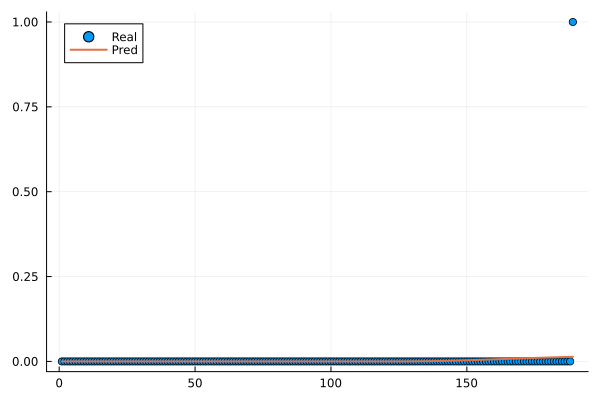

print device already activated


In [20]:
traj_plot = train_trajs[4]
t = traj_plot.t
y = traj_plot.y

pred_ude_n = predict_traj(ude!, p_trained_ude, traj_plot)

p1 = plot(
    t,
    y,
    seriestype = :scatter,
    label = "Real",
    markersize = 4
)

plot!(
    p1,
    t,
    pred_ude_n,
    label = "Pred",
    linewidth = 2
)

p1

##  UDE: término físico + red neuronal + sensores 

A partir de ahora vamos a incorporar la información de sensores al sistema.

$$
\frac{dz}{dt} = -\alpha z + NN(z,\tau,S(t))
$$

De esta parte en adelante vamos a realizar diferentes entrenamientos donde utilizamos una red neuronal y sus pesos. Para evitar utilizar pesos ya entrenados y hacerlo más limpio definimos la siguiente función:

In [21]:
function init_model(input_dim)

    nn = Lux.Chain(
        Lux.Dense(input_dim, 8, tanh),
        Lux.Dense(8, 1)
    )

    rng = MersenneTwister(1234)

    p, st = Lux.setup(rng, nn)

    return nn, ComponentArray(p), st
end

init_model (generic function with 1 method)

Modificamos la función para elegir trayectorias, agregando el parámetro sensors. Este parámetro nos va a permitir elegir que sensores queremos utilizar. Y además nos devuelve un test set

In [22]:
function build_train_test_trajs_sensors(trajectories;n_motors=nothing,test_ratio=0.2,shuffle=false,sensors=nothing,seed=67)

    total_motors = length(trajectories)

    selected_ids = collect(1:total_motors)

    # shuffle opcional (solo para definir el orden base)
    if shuffle
        rng = MersenneTwister(seed)
        selected_ids = selected_ids[randperm(rng, length(selected_ids))]
    end

    # elegir subset de motores
    if n_motors !== nothing
        n = min(n_motors, total_motors)
        println("usando $n de $total_motors motores")
        selected_ids = selected_ids[1:n]
    end

    # split train/test (20% test, siguientes en la lista)
    n_test = Int(round(test_ratio * length(selected_ids)))
    test_ids = selected_ids[end - n_test + 1:end]
    train_ids = selected_ids[1:end - n_test]

    # default sensors
    if sensors === nothing
        sensors = 4:size(trajectories[1].X, 2)
    end

    # helper para construir dataset
    function build(ids)
        trajs = []

        for i in ids

            t = Float64.(trajectories[i].t)
            S = Float64.(trajectories[i].X[:, sensors])

            sensor_interps = [
                LinearInterpolation(S[:, j], t)
                for j in 1:size(S,2)
            ]

            push!(trajs,
                (
                    sensor_interps = sensor_interps,
                    sensors_ids = sensors,
                    t = t,
                    y = Float64.(trajectories[i].y)
                )
            )
        end

        return trajs
    end

    train_trajs = build(train_ids)
    test_trajs  = build(test_ids)

    return train_trajs, test_trajs
end

build_train_test_trajs_sensors (generic function with 1 method)

In [23]:
function ude_sensors!(dz, z, p, τ, S)

    input = [z[1]; τ; S] 

    out, _ = nn2(input, p, st_ude_sensors)

    dz[1] = -α * z[1] + out[1]

end

ude_sensors! (generic function with 1 method)

In [ ]:
function predict_traj_sensors(p, traj)

    tvec = traj.t
    y = traj.y

    z0 = [-10.0] #seguimos con eso...

    t0 = tvec[1]
    tf = tvec[end]
    tspan = (t0, tf)

    function f!(du, z, p, t)

        S = [
            interp(clamp(t, t0, tf))
            for interp in traj.sensor_interps
        ]

        τ = (t - t0) / (tf - t0)

        ude_sensors!(du, z, p, τ, S)

    end

    prob = ODEProblem(f!, z0, tspan, p)

    sol = solve(
        prob,
        Tsit5(),
        saveat=tvec,
        abstol=1e-6,
        reltol=1e-6,
        dtmax=1.0
    )

    z_pred = Array(sol)[1, :]

    h_pred = σ.(z_pred)

    return h_pred

end

function loss_many_sensors(p, trajs)

    total_loss = 0f0
    total_points = 0
    pos_weight = 100f0 #le agrego peso en la loss al punto donde falla
    ϵ = 1f-7 #el epsilon es para no evaluar log(0)

    for traj in trajs
        h = predict_traj_sensors(p, traj)
        y = traj.y

        total_loss += -sum(pos_weight .* y .* log.(h .+ ϵ) .+ (1 .- y) .* log.(1 .- h .+ ϵ))
        total_points += length(y)
    end

    return total_loss / total_points

end

loss_many_sensors (generic function with 1 method)

Para la primera prueba tomamos sensores al azar

In [30]:
#Definimos un nuevo callback
callback = function (state, loss)

    global iter += 1

    if iter % 10 == 0
        println("Iteración: $iter / $maxiters | loss = $loss")

    end

    if loss < best_loss - 1e-6

        global best_loss = loss
        global best_params = deepcopy(state.u)

        global counter = 0

    else

        global counter += 1

    end

    if counter >= patience

        println("Early stopping activado")

        return true
    end

    return false
end

#40 (generic function with 1 method)

In [ ]:
train_trajs, test_trajs = build_train_test_trajs_sensors(
    trajectories;
    n_motors=10,
    sensors = [6,7]
)
n_sensors = length(train_trajs[1].sensor_interps)

println("Cantidad de sensores usados: ", n_sensors)

input_dim = 2 + n_sensors

nn2, p_ude_sensors, st_ude_sensors = init_model(input_dim)

α = 0.05

optf_ude_sensors = OptimizationFunction(
    (x, _) -> loss_many_sensors(x, train_trajs),
    AutoZygote()
)

optprob_ude_sensors = OptimizationProblem(
    optf_ude_sensors,
    p_ude_sensors
)

best_loss = Inf
best_params = nothing
patience = 30
counter = 0
iter = 0
maxiters = 1000


result_ude_sensors = @time Optimization.solve(
    optprob_ude_sensors,
    Adam(1e-3),
    maxiters=1000,
    callback=callback
)

p_trained_ude_sensors = best_params
#tardo 12 minutos

usando 10 de 100 motores
Cantidad de sensores usados: 2
Iteración: 10 / 1000 | loss = 1.1453852987252569
Iteración: 20 / 1000 | loss = 1.0913762467662946
Iteración: 30 / 1000 | loss = 1.046764278672698
Iteración: 40 / 1000 | loss = 1.008680205154347
Iteración: 50 / 1000 | loss = 0.9746848597340745
Iteración: 60 / 1000 | loss = 0.9431075924770214
Iteración: 70 / 1000 | loss = 0.9130186599638345
Iteración: 80 / 1000 | loss = 0.8841177010578544
Iteración: 90 / 1000 | loss = 0.8562794994184024
Iteración: 100 / 1000 | loss = 0.8289489175364811
Iteración: 110 / 1000 | loss = 0.8014905696068582
Iteración: 120 / 1000 | loss = 0.7735533653316673
Iteración: 130 / 1000 | loss = 0.7448191022675826
Iteración: 140 / 1000 | loss = 0.7148821013459152
Iteración: 150 / 1000 | loss = 0.6831869083698818
Iteración: 160 / 1000 | loss = 0.6489717223769281
Iteración: 170 / 1000 | loss = 0.6111730520123905
Iteración: 180 / 1000 | loss = 0.568188604238412
Iteración: 190 / 1000 | loss = 0.5176732232470748
Iterac

ComponentVector{Float32}(layer_1 = (weight = Float32[-1.2721745 -0.011280524 0.32793847 -0.95162845; -1.5059695 0.45568386 0.69188046 -1.1459538; … ; 0.9085021 -1.5379515 0.07973862 -0.9015315; 0.8480333 -0.6890251 -0.5981526 -0.90608525], bias = Float32[0.33107346, 0.40034947, -0.6548071, 0.087160125, -0.008529625, 0.67390627, -0.05608668, 0.27493924]), layer_2 = (weight = Float32[-0.38996452 -0.51193213 … 0.3365006 0.04910066], bias = Float32[-0.017361958]))

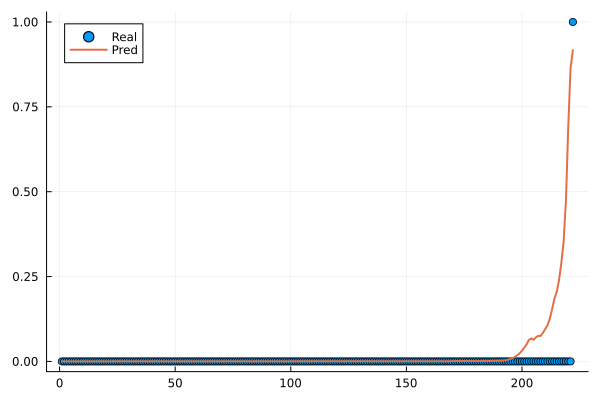

In [36]:
traj_plot = test_trajs[2]
t = traj_plot.t
y = traj_plot.y

pred_ude_sensors = predict_traj_sensors(
    p_trained_ude_sensors,
    traj_plot
)

p1 = plot(
    t,
    y,
    seriestype = :scatter,
    label = "Real",
    markersize = 4
)

plot!(
    p1,
    t,
    pred_ude_sensors,
    label = "Pred",
    linewidth = 2
)

p1

Le agregue peso en la loss al punto que falla y empieza a subir la curva. Habria que ver como se puede perfeccionar esto

### Que hice hasta aca:

+ NODE Y UDE sin sensores

+ UDE con sensores y peso en la loss

### Cosas que faltan de lo que teniamos antes:

+ probar los mejores sensores

+ probar distintos modelos

+ hacer un entrenamiento grande

### Cosas a considerar para esta nueva forma de plantear el problema

+ desbalanceo de clases